In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [29]:
titanic=sns.load_dataset('titanic')
titanic.head()
titanic.describe()
titanic.info()
titanic.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [30]:
features=['pclass','age','sex','fare','embarked']
target=['survived']

In [31]:
#missing data
from sklearn.impute import SimpleImputer
imp_median=SimpleImputer(strategy='median')
imp_median.fit_transform(titanic[['age']])

imp_freq=SimpleImputer(strategy='most_frequent')
titanic[['embarked']]=imp_freq.fit_transform(titanic[['embarked']])

In [32]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [33]:
#encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
titanic['sex']=le.fit_transform(titanic['sex'])
titanic['embarked']=le.fit_transform(titanic['embarked'])

In [34]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [35]:
x=titanic[features]
y=titanic[target]

In [36]:
x.head()

,pclass,age,sex,fare,embarked
0,3,22.0,1,7.2500,2
1,1,38.0,0,71.2833,0
2,3,26.0,0,7.9250,2
3,1,35.0,0,53.1000,2
4,3,35.0,1,8.0500,2


In [37]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [38]:
x_train.head()

,pclass,age,sex,fare,embarked
331,1,45.5,1,28.5000,2
733,2,23.0,1,13.0000,2
382,3,32.0,1,7.9250,2
704,3,26.0,1,7.8542,2
813,3,6.0,0,31.2750,2


In [39]:
# decision tree model (no purning)
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [40]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
y_pred=model.predict(x_test)

In [41]:
y_pred_train=model.predict(x_train)
print("Train Accuracy:", accuracy_score(y_train,y_pred_train))
print("Test Accuracy:", accuracy_score(y_test,y_pred))

Train Accuracy: 0.9789325842696629
Test Accuracy: 0.776536312849162


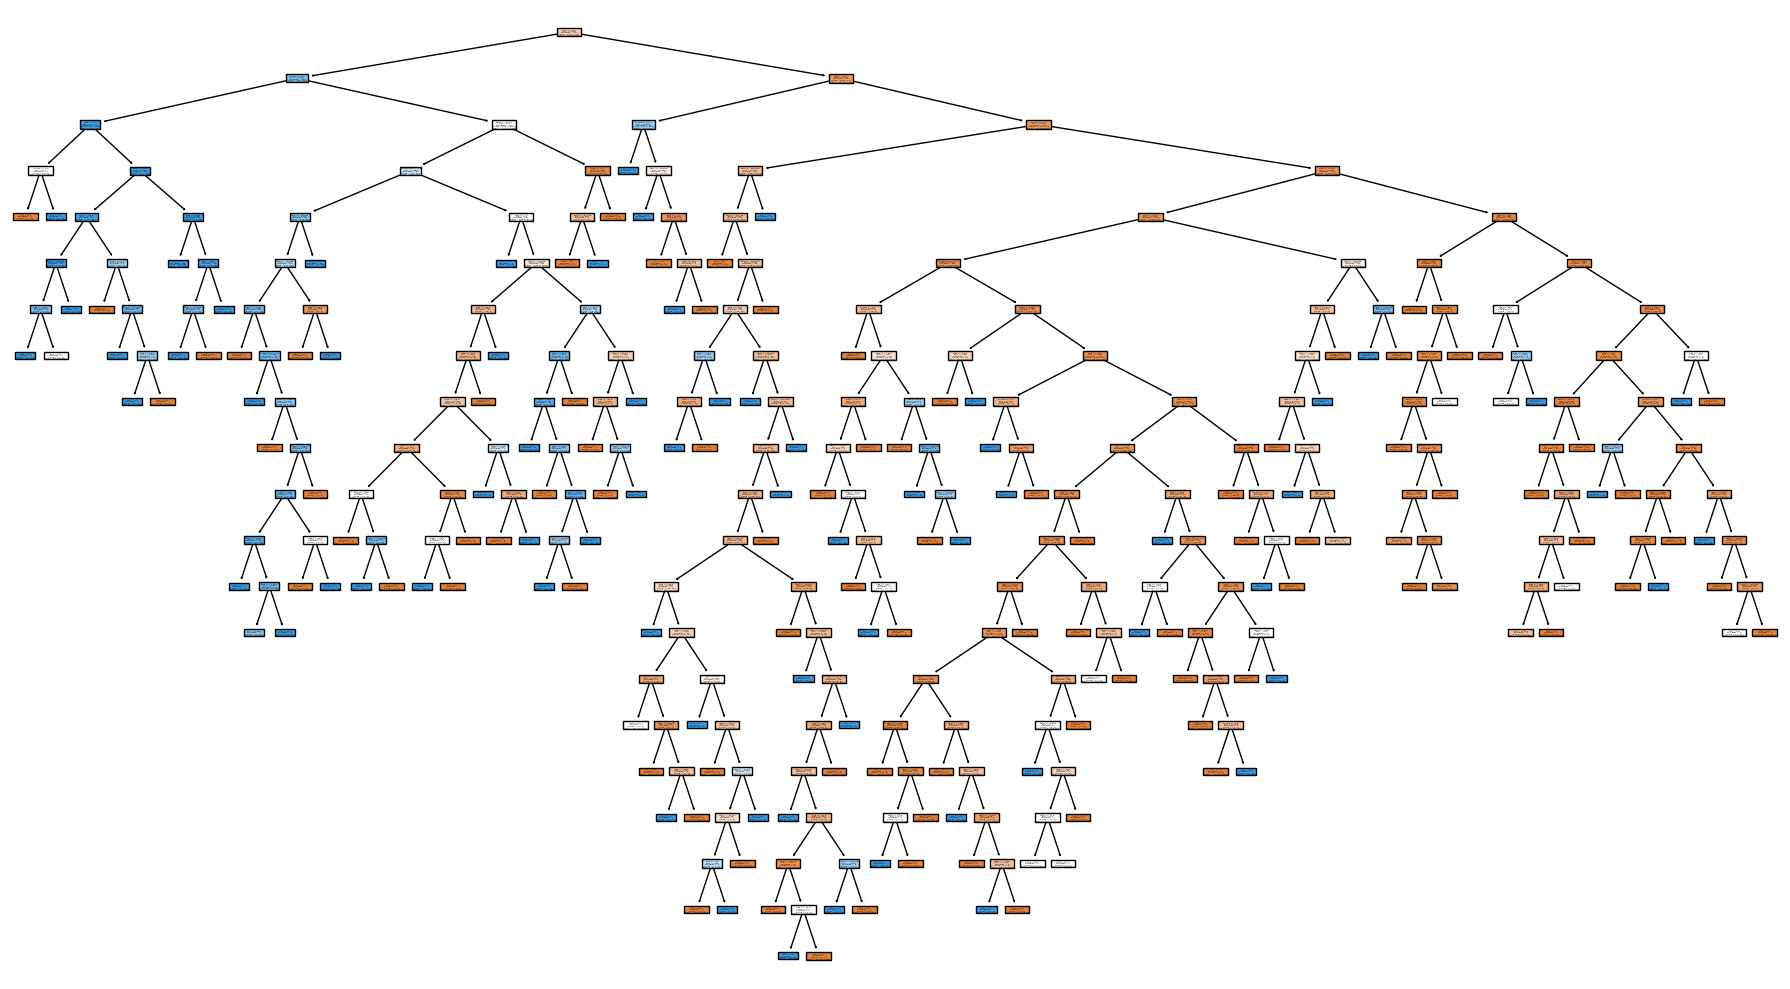

In [42]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(model,
          feature_names=x.columns,
          class_names=['not survived','survived'],
          filled=True)
plt.tight_layout()
plt.show()

In [43]:
#pre-pruning
max_depth=[2,3,4,5,6,7,8,9,10]
for i in max_depth:
    model=DecisionTreeClassifier(max_depth=i)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(f'max_depth={i} : {accuracy_score(y_test,y_pred)}')

max_depth=2 : 0.7653631284916201
max_depth=3 : 0.7988826815642458
max_depth=4 : 0.7988826815642458
max_depth=5 : 0.7932960893854749
max_depth=6 : 0.8044692737430168
max_depth=7 : 0.8044692737430168
max_depth=8 : 0.7932960893854749
max_depth=9 : 0.7988826815642458
max_depth=10 : 0.8100558659217877


In [44]:
min_samples_split=[2,3,4,5,6,7,8,9,10,20,30,40,50]
for i in min_samples_split:
    model=DecisionTreeClassifier(min_samples_split=i)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(f'min_samples_split={i} : {accuracy_score(y_test,y_pred)}')

min_samples_split=2 : 0.776536312849162
min_samples_split=3 : 0.7932960893854749
min_samples_split=4 : 0.7877094972067039
min_samples_split=5 : 0.7877094972067039
min_samples_split=6 : 0.7988826815642458
min_samples_split=7 : 0.8100558659217877
min_samples_split=8 : 0.8156424581005587
min_samples_split=9 : 0.8156424581005587
min_samples_split=10 : 0.8156424581005587
min_samples_split=20 : 0.8324022346368715
min_samples_split=30 : 0.8100558659217877
min_samples_split=40 : 0.8100558659217877
min_samples_split=50 : 0.8100558659217877


In [45]:
model=DecisionTreeClassifier(max_depth=7,min_samples_split=20)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

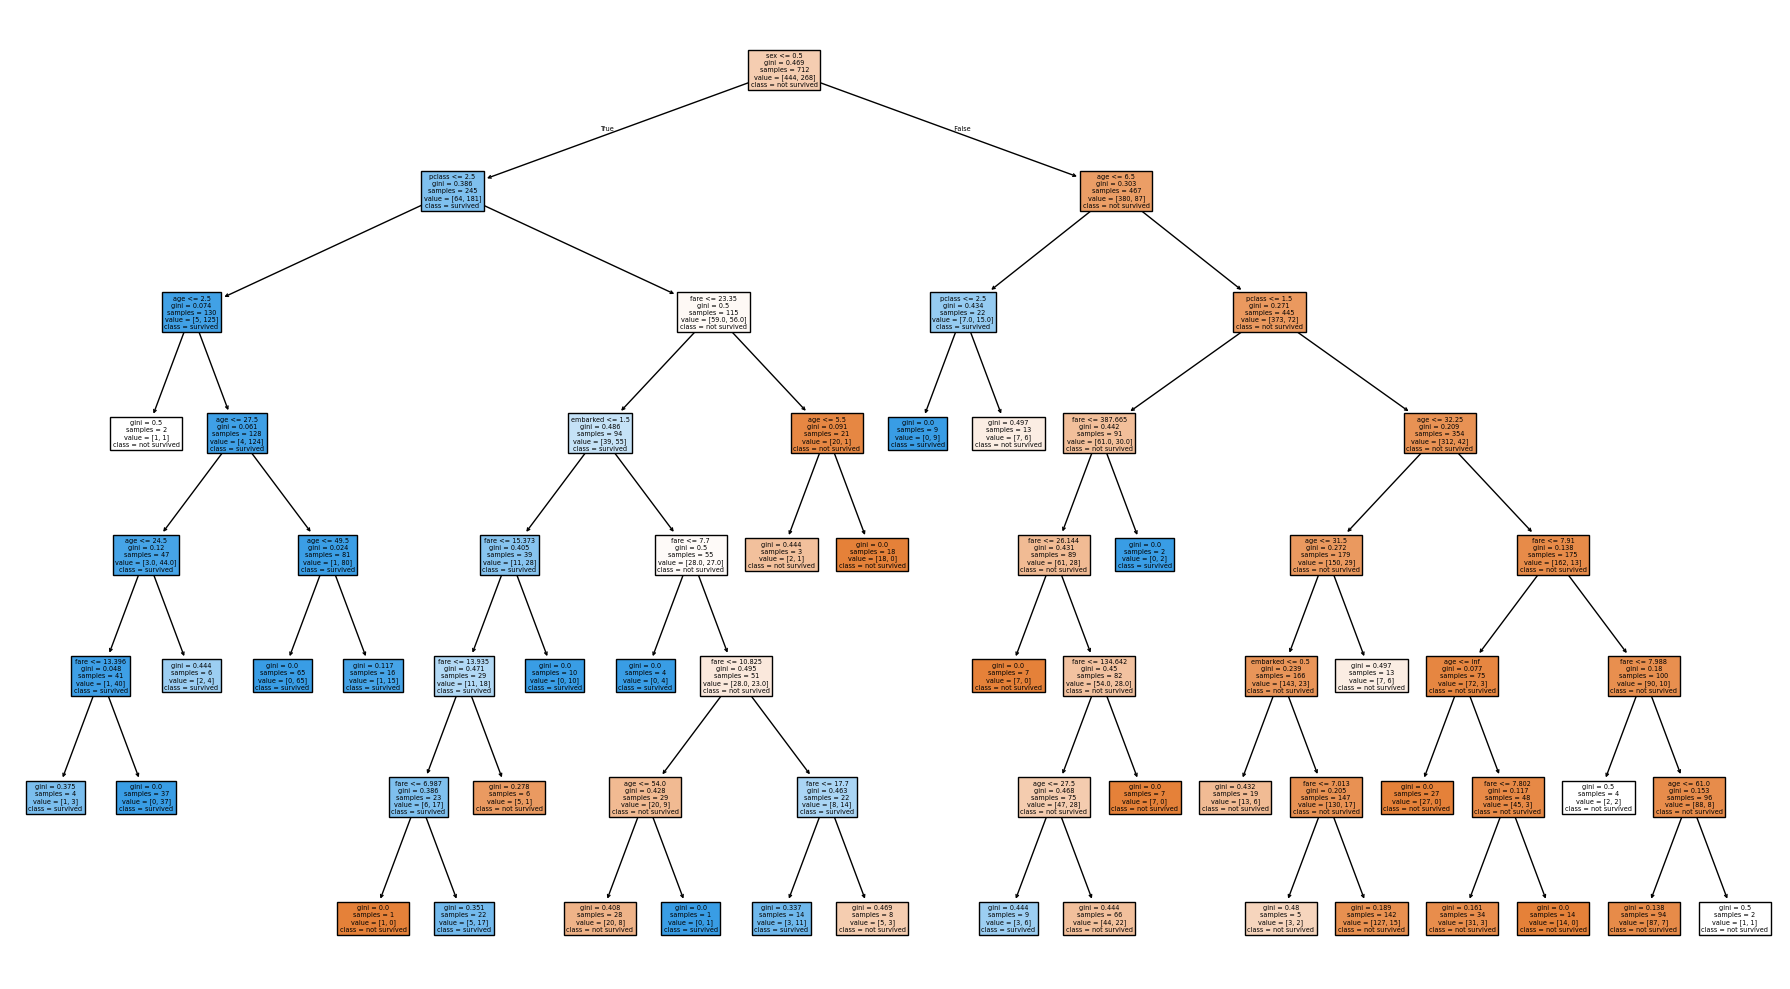

In [46]:
#plot the tree
plt.figure(figsize=(18,10))
plot_tree(model,
          feature_names=x.columns,
          class_names=['not survived','survived'],
          filled=True)
plt.tight_layout()
plt.show()

In [47]:
#post-pruning
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [48]:
path=full_tree.cost_complexity_pruning_path(x_train,y_train)

ccp_alphas=path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 5.67472478e-05 6.25888762e-05
 1.25893054e-04 1.83921883e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 3.70416101e-04 4.68164794e-04 4.72846442e-04
 5.58512386e-04 5.61797753e-04 5.61797753e-04 6.67991230e-04
 8.19288390e-04 8.42696629e-04 8.42696629e-04 8.77238365e-04
 8.77808989e-04 9.14036026e-04 9.24769963e-04 9.36329588e-04
 9.36329588e-04 9.88347898e-04 9.93949870e-04 1.07400895e-03
 1.12359551e-03 1.13237360e-03 1.17041199e-03 1.20642466e-03
 1.22893258e-03 1.22893258e-03 1.26404494e-03 1.28883014e-03
 1.30996111e-03 1.33761370e-03 1.37044603e-03 1.40014729e-03
 1.49812734e-03 1.51229549e-03 1.60434338e-03 1.67201712e-03
 1.67576935e-03 1.72860847e-03 1.75561798e-03 1.81649000e-03
 1.86337660e-03 1.86751451e-03 1.90081946e-03 2.10674157e-03
 2.14653267e-03 2.34082397e-03 2.41226470e-03 2.64273538e-03
 2.72281067e-03 3.43770913e-03 3.56327570e-03 5.47433606e-03
 9.05540038e-03 1.39295081e-02 1.59241633e-02 3.86053527e-02
 1.37779976e-01]


In [49]:
#train our model with different ccp_alpha values
tree=[]
for alpha in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(x_train,y_train)
    acc=model.score(x_test,y_test)

tree.append((model,alpha))

In [50]:
best_accuracy=0
best_alpha=0
for model,alpha in tree:
    if model.score(x_test,y_test)>best_accuracy:
        best_accuracy=model.score(x_test,y_test)
        best_alpha=alpha

In [51]:
best_accuracy

0.5865921787709497

In [52]:
# Find best alpha using cross-validation
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Get pruning path
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # remove the last (trivial) alpha

# Cross-validate each alpha
scores = []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    score = cross_val_score(dt, x_train, y_train, cv=5).mean()
    scores.append(score)

# Pick best alpha
best_alpha = ccp_alphas[np.argmax(scores)]
print("Best alpha:", best_alpha)

Best alpha: 0.009055400380113238


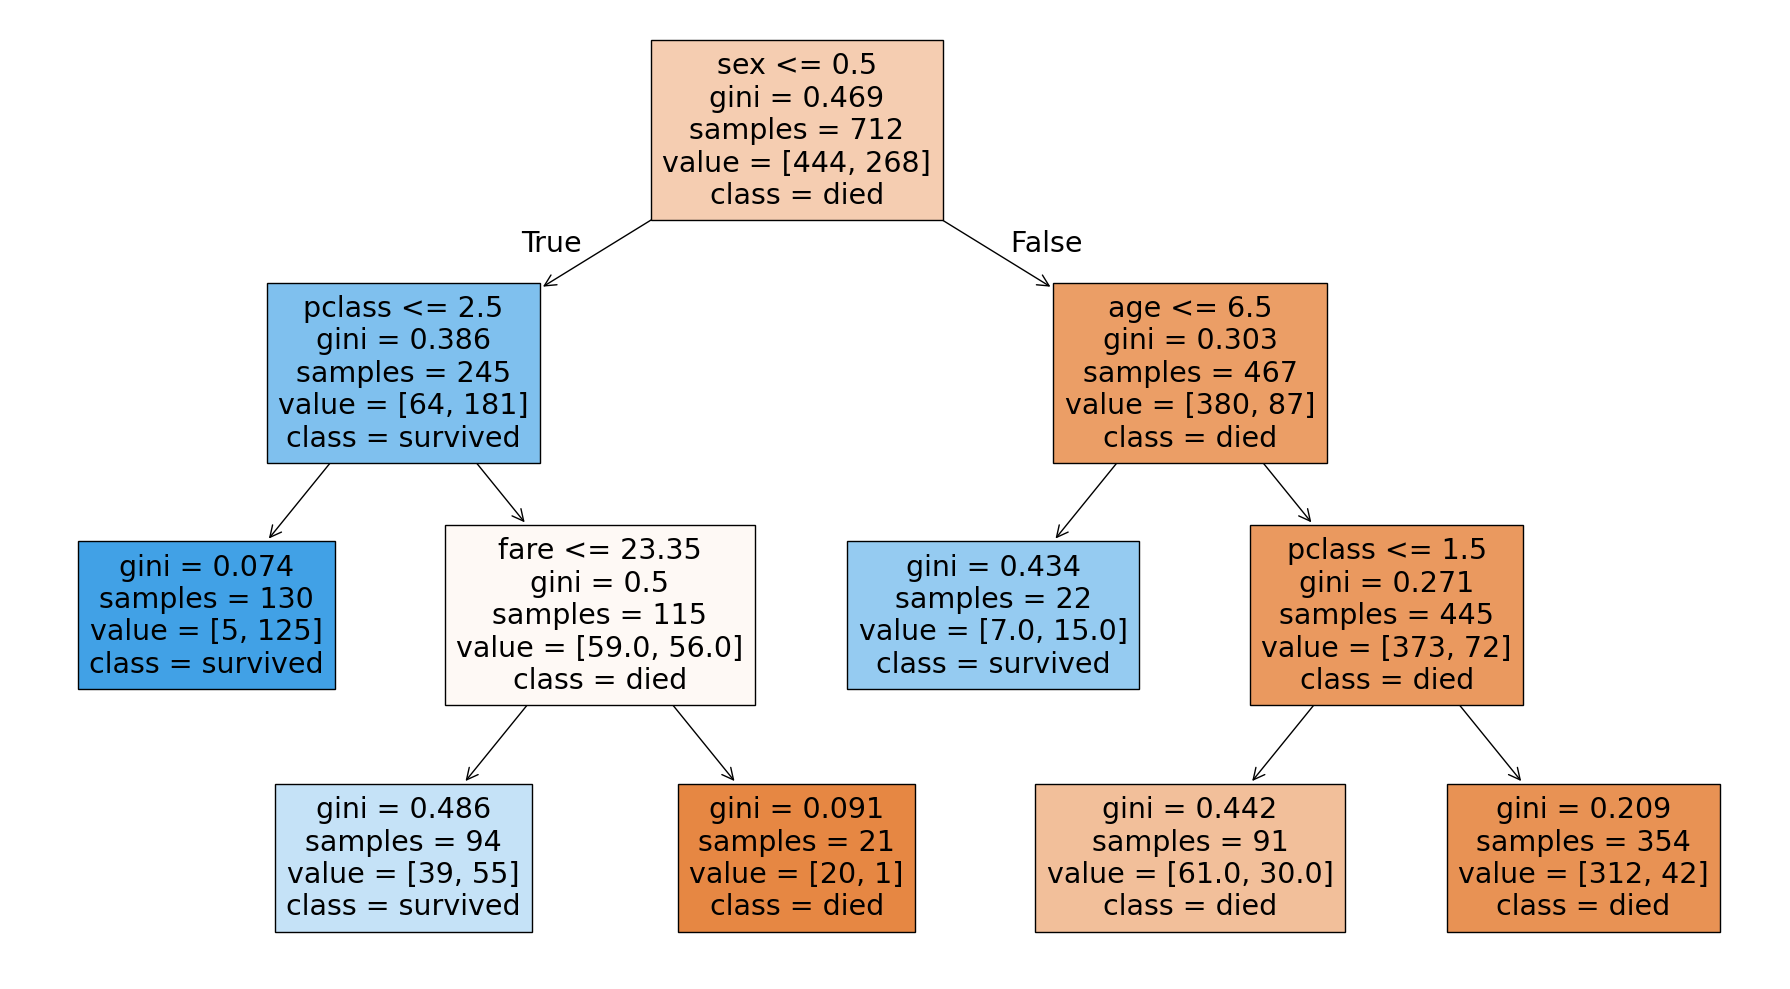

In [53]:
best_model= DecisionTreeClassifier( ccp_alpha=best_alpha)
best_model.fit(x_train,y_train)
plt.figure(figsize=(18,10))
plot_tree(best_model, feature_names=x_train.columns, class_names=["died","survived"], filled=True)
plt.tight_layout()
plt.show()

In [55]:
print(best_model.score(x_test,y_test))

0.7932960893854749


In [63]:
# as u can see the accuracy is not good but we can try to improve it by using ensemble methods like random forest and boosting algorithms.
# check out the accuracy scores of decision tree wihtout pruning in 14 code box 
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=301, oob_score=True , max_depth=4)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test,y_pred_rf))
print("OOB Score:", rf.oob_score_)

c:\Users\ADMIN\anaconda3\envs\mynewenv2\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Accuracy: 0.8212290502793296
OOB Score: 0.8230337078651685


In [66]:
# bagging classifier
from sklearn.ensemble import BaggingClassifier
base_model=DecisionTreeClassifier()
bagging =BaggingClassifier(base_model, n_estimators=201, random_state=42)
bagging.fit(x_train,y_train)
y_pred_bagging=bagging.predict(x_test)
print("Bagging Classifier Accuracy:", accuracy_score(y_test,y_pred_bagging))



c:\Users\ADMIN\anaconda3\envs\mynewenv2\Lib\site-packages\sklearn\ensemble\_bagging.py:988: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Bagging Classifier Accuracy: 0.8044692737430168


In [78]:
# Bagging Classifier
from sklearn.linear_model import LogisticRegression
import numpy as np

# Fix NaN values first
x_train = x_train.fillna(x_train.mean())
x_test = x_test.fillna(x_train.mean())

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(x_train, np.array(y_train).ravel())

y_pred_bagging = bagging.predict(x_test)

print("Bagging Classifier Accuracy:", accuracy_score(y_test, y_pred_bagging))

Bagging Classifier Accuracy: 0.7988826815642458
